In [1]:
import requests
import pandas as pd
import sqlite3

API_TOKEN = "f3391ee9cf8370f5f482727ce74929360a8a18aa"
ASSET_UID = "aPRutS6LChsVTzgdynWjYo"
BASE_URL = "https://eu.kobotoolbox.org"

headers = {
    "Authorization": f"Token {API_TOKEN}"}

url = f"{BASE_URL}/api/v2/assets/{ASSET_UID}/data/"
all_results = []

# Fetch data from the API with pagination
while url:
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()  # Raise an error for bad responses
    payload = response.json()

    results = payload.get("results", [])
    if not isinstance(results, list):
        raise ValueError(f"Unexpected API payload: {payload}")

    all_results.extend(results)
    url = payload.get("next")  # Get the next page URL

# Convert the results to a DataFrame
df = pd.DataFrame(all_results)
print(f"Pulled {len(df)} submissions.")
print(df.columns.tolist())

Pulled 1570 submissions.
['_id', 'start', 'end', 'Date_and_Time', 'Month', 'division', 'Premises', 'Food_Premises_Class', 'Name_of_Organization', 'Location', 'Take_a_picture_of_the_approach', 'Email_address', 'Contact_Person_Name', 'Contact_Person_Mobile_number', 'Any_other_Contact', 'Select_Documents_sighted', 'Do_you_sight_any_nuisance', 'Inspection_type', 'Inspector_Remarks', 'meta/instanceID', 'meta/rootUuid', 'meta/deprecatedID', 'formhub/uuid', '__version__', '_xform_id_string', '_uuid', '_attachments', '_status', '_geolocation', '_submission_time', '_validation_status', '_submitted_by', 'Nuisance_1_identified', 'Take_evidence', 'More_nuisances', 'Was_Abatement_Notice_served', 'Take_pictorial_evidence', 'Non_Food_Premises_Class', 'If_Others_Please_specify_001', 'Nuisance_2_Identified', 'Take_evidence_001', 'More_nuisances_001', 'Nuisance_3_Identified', 'More_nuisances_002', 'Take_evidence_002', 'Nuisance_4_Identified', 'Take_evidence_003', 'More_nuisances_003', 'Nuisance_5_Identi

In [2]:
# Find columns with problems

list_columns = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, list)).any()]
print("Columns containing lists:", list_columns)


Columns containing lists: ['_attachments', '_geolocation']


In [3]:
# Convert columns to plain text if they contain lists
for col in list_columns:
    df[col] = df[col].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x)

In [4]:
nested_columns = df.columns[
    df.map(lambda value: isinstance(value, (list, dict))).any()
]
print(nested_columns.tolist())

['_validation_status']


In [7]:
import json

df_sql = df.map(
    lambda value: json.dumps(value) if isinstance(value, (list, dict)) else value
)
conn = sqlite3.connect("kobo_data.db")
df_sql.to_sql("submissions", conn, if_exists="replace", index=False)

1570

In [8]:
# Push to sqlite

conn = sqlite3.connect("kobo_data.db")
df_sql.to_sql("submissions", conn, if_exists="replace", index=False)

print("Loaded into SQlite. Tables:")
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn).values.flatten())

Loaded into SQlite. Tables:
['submissions']


In [9]:
pd.read_sql("PRAGMA table_info(submissions);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,_id,INTEGER,0,None,0
1,1,start,TEXT,0,None,0
2,2,end,TEXT,0,None,0
3,3,Date_and_Time,TEXT,0,None,0
4,4,Month,TEXT,0,None,0
...,...,...,...,...,...,...
59,59,Nuisance_7_Identified,TEXT,0,None,0
60,60,Take_evidence_006,TEXT,0,None,0
61,61,If_Others_please_specify,TEXT,0,None,0
62,62,If_Yes_Name_001,TEXT,0,None,0


In [10]:
#Inspections per Division per Month

query = """
SELECT division, Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY division, Month
ORDER BY division, Month;
"""

pd.read_sql(query, conn)

,division,Month,inspection_count
0,1,january,1
1,Badagry_Division_1,April,2
2,Badagry_Division_1,August,11
3,Badagry_Division_1,December,4
4,Badagry_Division_1,February,22
5,Badagry_Division_1,July,8
6,Badagry_Division_1,June,6
7,Badagry_Division_1,March,19
8,Badagry_Division_1,May,6
9,Badagry_Division_1,November,6


In [11]:
pd.read_sql("SELECT division, COUNT(*) FROM submissions WHERE division = '1' GROUP BY division;", conn)
pd.read_sql("SELECT DISTINCT Do_you_sight_any_nuisance FROM submissions;", conn)
pd.read_sql("SELECT DISTINCT Nuisance_1_Identified FROM submissions LIMIT 20;", conn)

,Nuisance_1_identified
0,NaN
1,Insanitary heaped and deposition of refuse
2,Failure to provide toilet facilities
3,Insanitary overhanging of clothes in and aroun...
4,Defective ceiling ( pop)
5,Exposed refuse bin in the kitchen
6,Indiscriminate dumping of refuse on bare floor...
7,Evidence of flies infestation to the kitchen a...
8,Unscreened kitchen extractor leading to direct...
9,Insanitary dumping of refuse on the bare floor...


In [12]:
pd.read_sql("SELECT DISTINCT Do_you_sight_any_nuisance FROM submissions;", conn)

,Do_you_sight_any_nuisance
0,No_1
1,Compliant
2,Non-Compliant


In [13]:
pd.read_sql("SELECT Do_you_sight_any_nuisance, COUNT(*) FROM submissions GROUP BY Do_you_sight_any_nuisance;", conn)

,Do_you_sight_any_nuisance,COUNT(*)
0,Compliant,577
1,No_1,4
2,Non-Compliant,989


In [14]:
# Overall Compliance Rate

query = """
SELECT
    Do_you_sight_any_nuisance AS compliance_status,
    COUNT(*) AS count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM submissions), 2) AS percentage
FROM submissions
GROUP BY Do_you_sight_any_nuisance;
"""

pd.read_sql(query, conn)

,compliance_status,count,percentage
0,Compliant,577,36.75
1,No_1,4,0.25
2,Non-Compliant,989,62.99


In [15]:
# Compliance rate by division

query = """
SELECT
    division,
    SUM(CASE WHEN Do_you_sight_any_nuisance = 'Compliant' THEN 1 ELSE 0 END) AS compliant_count,
    SUM(CASE WHEN Do_you_sight_any_nuisance = 'Non-Compliant' THEN 1 ELSE 0 END) AS non_compliant_count,
    COUNT(*) AS total_inspections,
    ROUND(100.0 * SUM(CASE WHEN Do_you_sight_any_nuisance = 'Compliant' THEN 1 ELSE 0 END) / COUNT(*), 1) AS compliance_rate_pct
FROM submissions
GROUP BY division
ORDER BY compliance_rate_pct DESC;
"""

pd.read_sql(query, conn)

,division,compliant_count,non_compliant_count,total_inspections,compliance_rate_pct
0,Ikorodu-Epe_Division_1,287,86,373,76.9
1,Badagry_Division_1,45,91,136,33.1
2,Lagos_Island_Division_1,221,631,854,25.9
3,Ikeja_Division_1,24,181,206,11.7
4,1,0,0,1,0.0


In [16]:
# Inspections per division per month
query = """
SELECT division, Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY division, Month
ORDER BY division, Month;
"""

pd.read_sql(query, conn)

,division,Month,inspection_count
0,1,january,1
1,Badagry_Division_1,April,2
2,Badagry_Division_1,August,11
3,Badagry_Division_1,December,4
4,Badagry_Division_1,February,22
5,Badagry_Division_1,July,8
6,Badagry_Division_1,June,6
7,Badagry_Division_1,March,19
8,Badagry_Division_1,May,6
9,Badagry_Division_1,November,6


In [17]:
# Trend over time
query = """
SELECT Month, COUNT(*) AS inspection_count
FROM submissions
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql(query, conn)

,Month,inspection_count
0,April,176
1,August,112
2,December,51
3,February,150
4,January,1
5,July,147
6,June,117
7,March,184
8,May,148
9,November,107


In [18]:
# Nuisance type breakdown
query = """
SELECT nuisance_type, COUNT(*) AS occurrences
FROM(
    SELECT Nuisance_1_Identified AS nuisance_type FROM submissions WHERE Nuisance_1_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_2_Identified FROM submissions WHERE Nuisance_2_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_3_Identified FROM submissions WHERE Nuisance_3_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_4_Identified FROM submissions WHERE Nuisance_4_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_5_Identified FROM submissions WHERE Nuisance_5_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_6_Identified FROM submissions WHERE Nuisance_6_Identified IS NOT NULL
    UNION ALL
    SELECT Nuisance_7_Identified FROM submissions WHERE Nuisance_7_Identified IS NOT NULL
) AS all_nuisances
GROUP BY nuisance_type
ORDER BY occurrences DESC;
"""

pd.read_sql(query, conn)

,nuisance_type,occurrences
0,Accumulation of miscellaneous articles,17
1,Accumulation of miscellaneous articles,13
2,Defective fat trap,11
3,Insanitary refuse bin,9
4,Evidence of excessive heat inside the kitchen ...,7
...,...,...
2616,1.Insanitary toilet pit latrine emitting offen...,1
2617,1.Insanitary production leading to exposing o...,1
2618,1. Indiscriminate/illegal dumping of waste (re...,1
2619,1. Failed to provide a toilet facility within ...,1


In [20]:
# Make Date and Time proper

df['Date_and_Time'] = pd.to_datetime(df['Date_and_Time'], errors='coerce')

In [21]:
df['Date_and_Time'].dtype

datetime64[us, UTC+01:00]

In [23]:
# Montly inspection counts

monthly_inspections = (
    df.set_index('Date_and_Time')
    .resample('ME')
    .size()
)

In [24]:
monthly_inspections

Date_and_Time
2024-09-30 00:00:00+01:00    16
2024-10-31 00:00:00+01:00    18
2024-11-30 00:00:00+01:00     0
2024-12-31 00:00:00+01:00     0
2025-01-31 00:00:00+01:00     0
2025-02-28 00:00:00+01:00    61
2025-03-31 00:00:00+01:00    52
2025-04-30 00:00:00+01:00    24
2025-05-31 00:00:00+01:00    21
2025-06-30 00:00:00+01:00    23
2025-07-31 00:00:00+01:00    26
2025-08-31 00:00:00+01:00     4
2025-09-30 00:00:00+01:00     5
2025-10-31 00:00:00+01:00    23
2025-11-30 00:00:00+01:00     7
2025-12-31 00:00:00+01:00     6
2026-01-31 00:00:00+01:00     0
2026-02-28 00:00:00+01:00     6
2026-03-31 00:00:00+01:00     1
2026-04-30 00:00:00+01:00     0
2026-05-31 00:00:00+01:00     0
2026-06-30 00:00:00+01:00     0
2026-07-31 00:00:00+01:00     0
2026-08-31 00:00:00+01:00     2
2026-09-30 00:00:00+01:00    11
dtype: int64

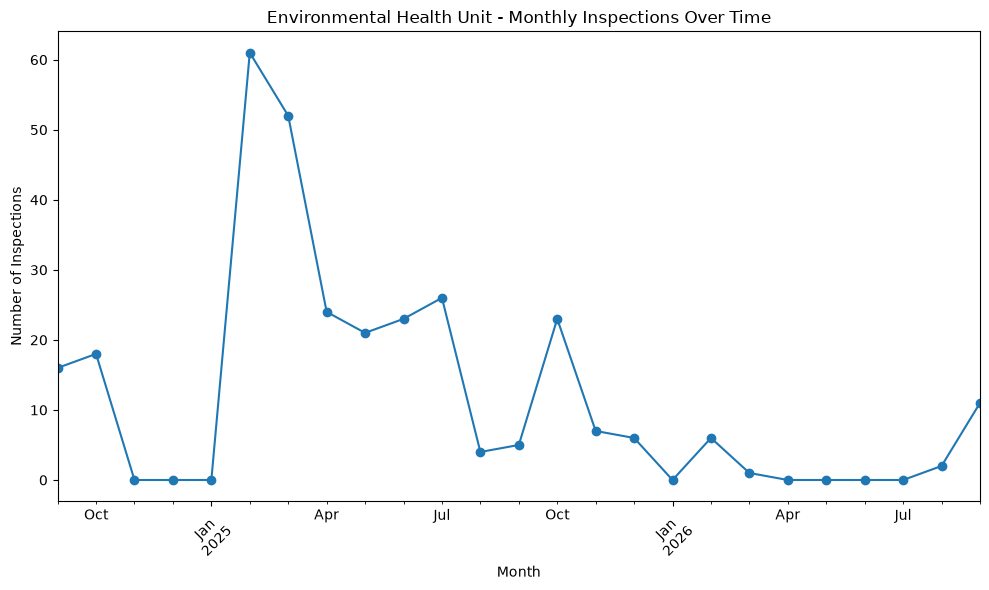

In [25]:
# Visualization of Monthly Inspections in Line Chart
import matplotlib.pyplot as plt

monthly_inspections.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Environmental Health Unit - Monthly Inspections Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
# Monthly/Division Table

division_monthly = (
    df.groupby([
        pd.Grouper(key='Date_and_Time', freq='ME'),
        'division'
    ])
    .size()
    .reset_index(name='inspection_count')
)

division_monthly.head()

,Date_and_Time,division,inspection_count
0,2024-09-30 00:00:00+01:00,Badagry_Division_1,9
1,2024-09-30 00:00:00+01:00,Ikeja_Division_1,1
2,2024-09-30 00:00:00+01:00,Lagos_Island_Division_1,6
3,2024-10-31 00:00:00+01:00,Badagry_Division_1,18
4,2025-02-28 00:00:00+01:00,Badagry_Division_1,12


In [ ]:
# Visualization of Monthly Inspections by Division
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=division_monthly,
    x='Date_and_Time',
    y='inspection_count',
    hue='division'
    marker='o',
)

plt.title('Environmental Health Unit - Monthly Inspections by Division')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45)

plt.legend(title='Division')
plt.tight_layout()
plt.show()